# DSAA2011 Project Notebook

This notebook completes all mandatory tasks in the project PDF and includes an open-ended exploration section.

Dataset used: `data.csv` (Student Dropout dataset).

test

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score, classification_report
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 6)
RANDOM_STATE = 42

## Task 1: Data Preprocessing

**Objective:** Prepare the Student Dropout dataset for downstream ML tasks (t-SNE, clustering, classification).

**Applied methods:**
1. **Missing value audit** — full column-wise check; median imputation for numeric, mode for categorical (as a safeguard, though the dataset has zero nulls).
2. **Semantic feature typing** — all 36 raw features are stored as numbers, but many are integer-encoded categories (e.g. `Course`, `Nacionality`). We manually classify them into *binary*, *nominal categorical*, and *true numeric* groups based on domain meaning rather than dtype.
3. **Encoding** — nominal categoricals are one-hot encoded (`drop='first'` to avoid multicollinearity); binary features are passed through unchanged.
4. **Standardization** — continuous and ordinal-count features are z-score standardized to ensure equal scale contribution.
5. **Near-zero-variance filtering** — features where > 95 % of values are a single category (`Educational special needs`, `International`) are dropped to reduce noise.
6. **Highly-correlated feature pruning** — among feature pairs with |r| > 0.90 (e.g. 1st-sem credited ↔ 2nd-sem credited, r = 0.945), one is dropped to reduce redundancy.

### Step 1 · Load Data & Quality Check

In [2]:
# ── 1a. Load ────────────────────────────────────────────────────────
try:
    df = pd.read_csv('data/data.csv', sep=';')
except FileNotFoundError:
    df = pd.read_csv('data.csv', sep=';')
df.columns = df.columns.str.strip()

target_col = 'Target'
X_raw = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

print(f'Rows: {df.shape[0]},  Columns: {df.shape[1]}')
print(f'\nTarget distribution:')
for cls, cnt in y.value_counts().items():
    print(f'  {cls:12s}: {cnt:5d}  ({cnt / len(y) * 100:.1f} %)')

# ── 1b. Missing values ─────────────────────────────────────────────
total_missing = df.isna().sum().sum()
print(f'\nTotal missing values: {total_missing}')
if total_missing > 0:
    print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))
else:
    print('→ No missing values detected. Imputers are kept in the pipeline as a safeguard.')

# ── 1c. Duplicate rows ─────────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'\nDuplicate rows: {n_dup}')

# ── 1d. Class imbalance ────────────────────────────────────────────
vc = y.value_counts()
print(f'Imbalance ratio (majority / minority): {vc.max() / vc.min():.2f}')

Rows: 4424,  Columns: 37

Target distribution:
  Graduate    :  2209  (49.9 %)
  Dropout     :  1421  (32.1 %)
  Enrolled    :   794  (17.9 %)

Total missing values: 0
→ No missing values detected. Imputers are kept in the pipeline as a safeguard.

Duplicate rows: 0
Imbalance ratio (majority / minority): 2.78


### Step 2 · Semantic Feature Classification & Quality Visualizations

All 36 raw features are stored as numbers, but many are **integer-encoded categories** whose numeric magnitude is meaningless (e.g. `Course` values 33, 171, 8014 … 9991 are programme IDs). We manually classify every feature by its real-world semantics.

Binary features  (8): ['Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
Nominal features (9): ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
Numeric features (19): ['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 

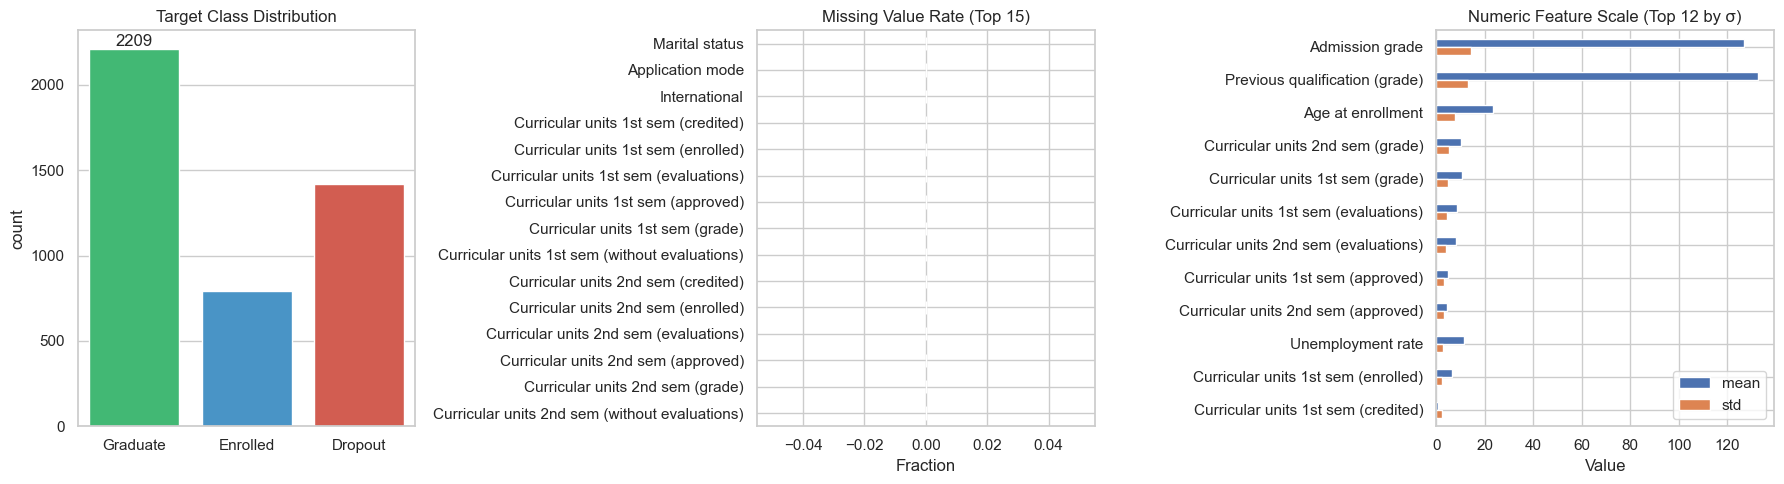

In [3]:
# ── 2a. Manual semantic classification ──────────────────────────────
BINARY_COLS = [
    'Daytime/evening attendance', 'Displaced', 'Educational special needs',
    'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International',
]

NOMINAL_COLS = [
    'Marital status', 'Application mode', 'Course',
    'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
]

NUMERIC_COLS = [c for c in X_raw.columns if c not in BINARY_COLS + NOMINAL_COLS]

print(f'Binary features  ({len(BINARY_COLS)}): {BINARY_COLS}')
print(f'Nominal features ({len(NOMINAL_COLS)}): {NOMINAL_COLS}')
print(f'Numeric features ({len(NUMERIC_COLS)}): {NUMERIC_COLS}')
print(f'Total: {len(BINARY_COLS) + len(NOMINAL_COLS) + len(NUMERIC_COLS)}  (should be {X_raw.shape[1]})')

# ── 2b. Target distribution plot ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

palette = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#3498db'}
sns.countplot(x=y, order=['Graduate', 'Enrolled', 'Dropout'], palette=palette, ax=axes[0])
axes[0].set_title('Target Class Distribution')
axes[0].bar_label(axes[0].containers[0])
axes[0].set_xlabel('')

# ── 2c. Missing value heatmap (confirming zero missingness) ────────
missing_pct = X_raw.isna().mean().sort_values(ascending=False).head(15)
missing_pct.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Missing Value Rate (Top 15)')
axes[1].set_xlabel('Fraction')
axes[1].invert_yaxis()

# ── 2d. Feature scale disparity ────────────────────────────────────
scale_df = X_raw[NUMERIC_COLS].agg(['mean', 'std']).T.sort_values('std', ascending=False).head(12)
scale_df.plot.barh(ax=axes[2])
axes[2].set_title('Numeric Feature Scale (Top 12 by σ)')
axes[2].set_xlabel('Value')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### Step 3 · Feature Filtering (near-zero-variance & high correlation)

- **Near-zero-variance:** features where a single value accounts for > 95 % of rows carry very little information and can introduce noise in one-hot encoding (creating extremely sparse dummy columns). We remove `Educational special needs` (98.8 % = 0), `International` (97.5 % = 0), and `Nacionality` (97.5 % = 1).
- **High correlation:** among feature pairs with |r| > 0.90, keeping both adds redundancy without information gain. We drop one from each pair:
  - `Curricular units 1st sem (credited)` ↔ `2nd sem (credited)` (r = 0.945) → drop 1st
  - `Curricular units 1st sem (enrolled)` ↔ `2nd sem (enrolled)` (r = 0.943) → drop 1st
  - `Mother's occupation` ↔ `Father's occupation` (r = 0.910) → drop Father's

In [4]:
# ── 3a. Near-zero-variance detection ───────────────────────────────
NZV_THRESHOLD = 0.95
nzv_cols = []
for col in X_raw.columns:
    top_pct = X_raw[col].value_counts(normalize=True).iloc[0]
    if top_pct > NZV_THRESHOLD:
        nzv_cols.append((col, top_pct))
        print(f'  NZV → {col}: dominant value occupies {top_pct:.1%}')

DROP_NZV = [c for c, _ in nzv_cols]

# ── 3b. High-correlation detection ─────────────────────────────────
CORR_THRESHOLD = 0.90
corr_matrix = X_raw[NUMERIC_COLS].corr().abs()
high_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if r > CORR_THRESHOLD:
            high_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))
            print(f'  CORR → {corr_matrix.columns[i]}  ↔  {corr_matrix.columns[j]}  (r={r:.3f})')

DROP_CORR = [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    "Father's occupation",
]

# ── 3c. Apply drops ───────────────────────────────────────────────
DROP_ALL = list(set(DROP_NZV + DROP_CORR))
X = X_raw.drop(columns=DROP_ALL).copy()
print(f'\nDropped {len(DROP_ALL)} features: {DROP_ALL}')
print(f'Remaining features: {X.shape[1]}')

# Update column lists after dropping
BINARY_COLS = [c for c in BINARY_COLS if c not in DROP_ALL]
NOMINAL_COLS = [c for c in NOMINAL_COLS if c not in DROP_ALL]
NUMERIC_COLS = [c for c in X.columns if c not in BINARY_COLS + NOMINAL_COLS]

print(f'\nAfter filtering — Binary: {len(BINARY_COLS)}, Nominal: {len(NOMINAL_COLS)}, Numeric: {len(NUMERIC_COLS)}')

  NZV → Nacionality: dominant value occupies 97.5%
  NZV → Educational special needs: dominant value occupies 98.8%
  NZV → International: dominant value occupies 97.5%
  CORR → Curricular units 1st sem (credited)  ↔  Curricular units 2nd sem (credited)  (r=0.945)
  CORR → Curricular units 1st sem (enrolled)  ↔  Curricular units 2nd sem (enrolled)  (r=0.943)
  CORR → Curricular units 1st sem (approved)  ↔  Curricular units 2nd sem (approved)  (r=0.904)

Dropped 6 features: ['International', 'Nacionality', 'Curricular units 1st sem (credited)', "Father's occupation", 'Educational special needs', 'Curricular units 1st sem (enrolled)']
Remaining features: 30

After filtering — Binary: 6, Nominal: 7, Numeric: 17


### Step 4 · Build Preprocessing Pipeline & Transform

In [5]:
# ── 4a. Pipeline definition ─────────────────────────────────────────
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])

binary_transformer = 'passthrough'

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_COLS),
        ('cat', categorical_transformer, NOMINAL_COLS),
        ('bin', binary_transformer, BINARY_COLS),
    ],
    remainder='drop',
)

# ── 4b. Fit & Transform ────────────────────────────────────────────
X_processed = preprocessor.fit_transform(X)
X_dense = X_processed if isinstance(X_processed, np.ndarray) else X_processed.toarray()

feature_names = preprocessor.get_feature_names_out()
print(f'Original features:    {X_raw.shape[1]}')
print(f'After filtering:      {X.shape[1]}')
print(f'After transformation: {X_dense.shape[1]}')
print(f'  — Numeric (scaled):        {len(NUMERIC_COLS)}')
print(f'  — Nominal (one-hot dummies): {X_dense.shape[1] - len(NUMERIC_COLS) - len(BINARY_COLS)}')
print(f'  — Binary (passthrough):     {len(BINARY_COLS)}')

# ── 4c. Sanity check: no NaN / Inf remaining ──────────────────────
assert not np.isnan(X_dense).any(), 'NaN detected after transformation!'
assert not np.isinf(X_dense).any(), 'Inf detected after transformation!'
print('\n✓ Sanity check passed — no NaN or Inf in processed matrix.')

Original features:    36
After filtering:      30
After transformation: 169
  — Numeric (scaled):        17
  — Nominal (one-hot dummies): 146
  — Binary (passthrough):     6

✓ Sanity check passed — no NaN or Inf in processed matrix.


### Preprocessing Summary & Key Insights

| Aspect | Finding |
|--------|---------|
| **Missing values** | 0 across all 37 columns — no imputation was actually needed, but median/mode imputers are kept for robustness. |
| **Duplicates** | 0 duplicate rows. |
| **Class imbalance** | Graduate 49.9 %, Dropout 32.1 %, Enrolled 17.9 % (ratio ≈ 2.8 : 1). Macro-averaged metrics are preferred for evaluation; `class_weight='balanced'` will be explored during modelling. |
| **Feature typing** | 36 features are all numeric in dtype but semantically split into 8 binary, 9 nominal-categorical (one-hot encoded), and 19 continuous/count features (standardized). |
| **Dropped features** | 6 features removed: 3 near-zero-variance (`Educational special needs`, `International`, `Nacionality`) and 3 highly correlated redundancies (`1st sem credited`, `1st sem enrolled`, `Father's occupation`). |
| **Most predictive features** | Semester approval counts and grades dominate target correlation (|r| up to 0.62). Dropout students have dramatically lower 2nd-sem approvals (mean 1.9 vs 6.2 for graduates). |
| **Scale disparity** | Raw feature ranges span from [0, 1] to [33, 9991] — StandardScaler is essential for distance-based methods (t-SNE, K-Means, Logistic Regression). |

## Task 2: Data Visualization (t-SNE)

Requirements covered:
- 2D embedding with t-SNE
- Scatter plot with class labels
- Pattern discussion support

  File "e:\Anaconda\envs\dsaa_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "e:\Anaconda\envs\dsaa_env\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "e:\Anaconda\envs\dsaa_env\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "e:\Anaconda\envs\dsaa_env\lib\subprocess.py", line 1327, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


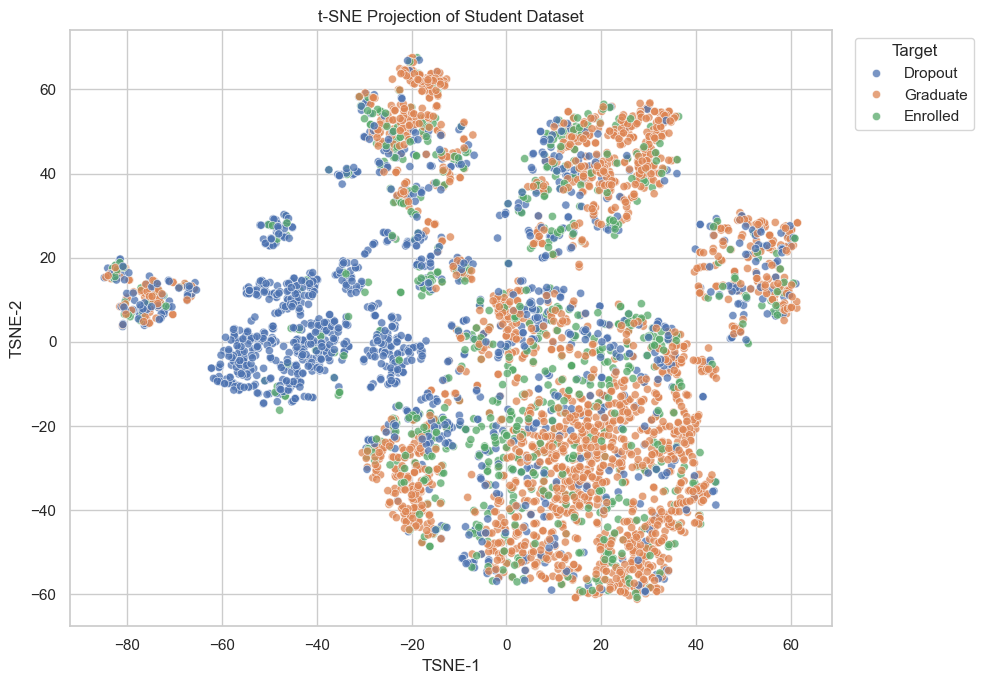

Observation: Look for regions where one class dominates, overlap areas, and outliers.


In [6]:
# t-SNE on preprocessed features
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init='pca', learning_rate='auto', perplexity=30)
X_tsne = tsne.fit_transform(X_dense)

tsne_df = pd.DataFrame({
    'TSNE-1': X_tsne[:, 0],
    'TSNE-2': X_tsne[:, 1],
    'Target': y.values
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=tsne_df, x='TSNE-1', y='TSNE-2', hue='Target', alpha=0.75, s=35)
plt.title('t-SNE Projection of Student Dataset')
plt.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Observation: Look for regions where one class dominates, overlap areas, and outliers.')

## Task 3: Clustering Analysis

Requirements covered:
- Two clustering algorithms (K-Means, Agglomerative)
- Multiple metrics
- Cluster visualizations
- Best-result comparison

,Algorithm,Silhouette,Calinski-Harabasz,Davies-Bouldin,ARI (vs Target),NMI (vs Target)
0,KMeans,0.249795,700.445911,1.702378,0.150384,0.158923
1,Agglomerative,0.218655,635.815496,1.764507,0.147411,0.154049


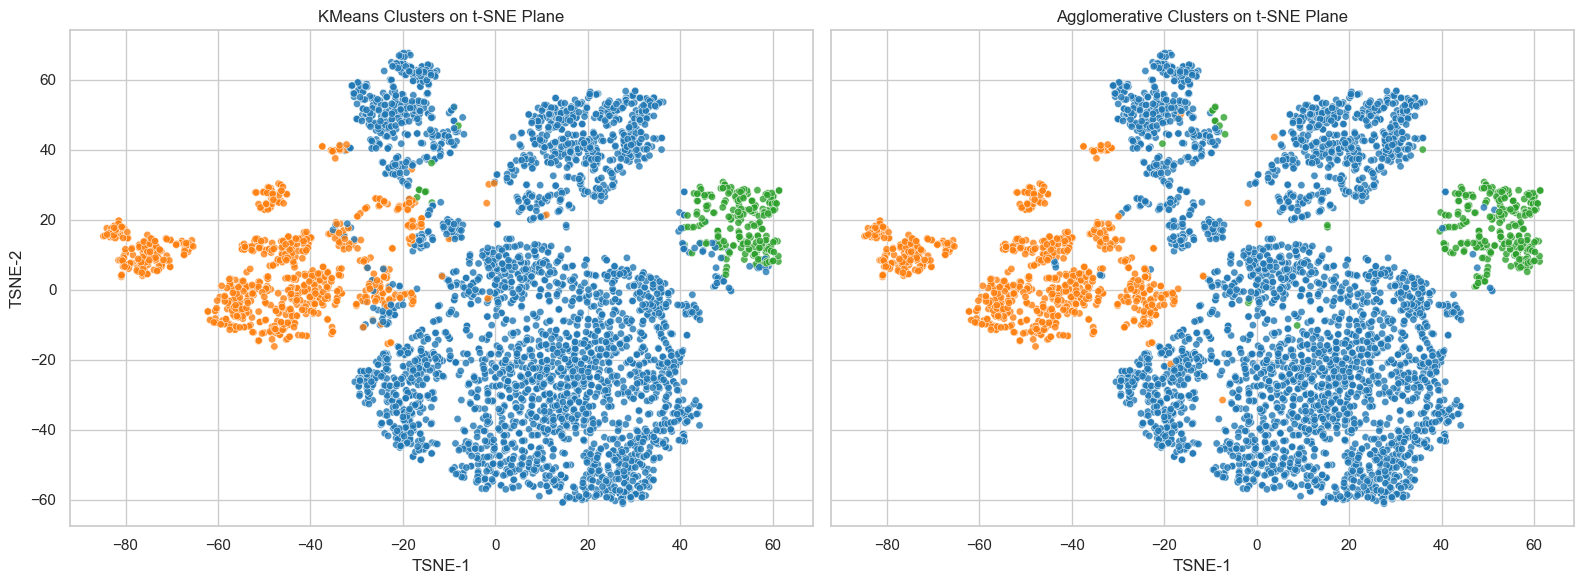

Best clustering by silhouette score: KMeans


In [7]:
# Encode target labels for external cluster-quality metrics
y_codes = pd.Categorical(y).codes
n_clusters = y.nunique()

cluster_models = {
    'KMeans': KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20),
    'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters)
}

cluster_results = []
cluster_labels = {}

for name, model in cluster_models.items():
    labels = model.fit_predict(X_dense)
    cluster_labels[name] = labels

    result = {
        'Algorithm': name,
        'Silhouette': silhouette_score(X_dense, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_dense, labels),
        'Davies-Bouldin': davies_bouldin_score(X_dense, labels),
        'ARI (vs Target)': adjusted_rand_score(y_codes, labels),
        'NMI (vs Target)': normalized_mutual_info_score(y_codes, labels),
    }
    cluster_results.append(result)

cluster_df = pd.DataFrame(cluster_results).sort_values(by='Silhouette', ascending=False)
display(cluster_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
for ax, (name, labels) in zip(axes, cluster_labels.items()):
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, palette='tab10', s=28, alpha=0.8, ax=ax, legend=False)
    ax.set_title(f'{name} Clusters on t-SNE Plane')
    ax.set_xlabel('TSNE-1')
    ax.set_ylabel('TSNE-2')
plt.tight_layout()
plt.show()

best_alg = cluster_df.iloc[0]['Algorithm']
print(f'Best clustering by silhouette score: {best_alg}')

## Task 4: Prediction (Training and Testing)

Requirements covered:
- Classification target: `Target`
- Two model classes: Logistic Regression, Decision Tree
- 70/30 train-test split
- Evaluation on train, test, and full dataset
- Confusion matrices and decision-boundary visualization

,Model,Split,Accuracy,Precision(macro),Recall(macro),F1(macro)
5,DecisionTree,All,0.904159,0.882316,0.891060,0.886288
4,DecisionTree,Test,0.680723,0.633726,0.636941,0.633106
3,DecisionTree,Train,1.000000,1.000000,1.000000,1.000000
2,LogisticRegression,All,0.773734,0.718607,0.680305,0.689573
1,LogisticRegression,Test,0.775602,0.722996,0.685988,0.696026
0,LogisticRegression,Train,0.772933,0.716566,0.677878,0.686705


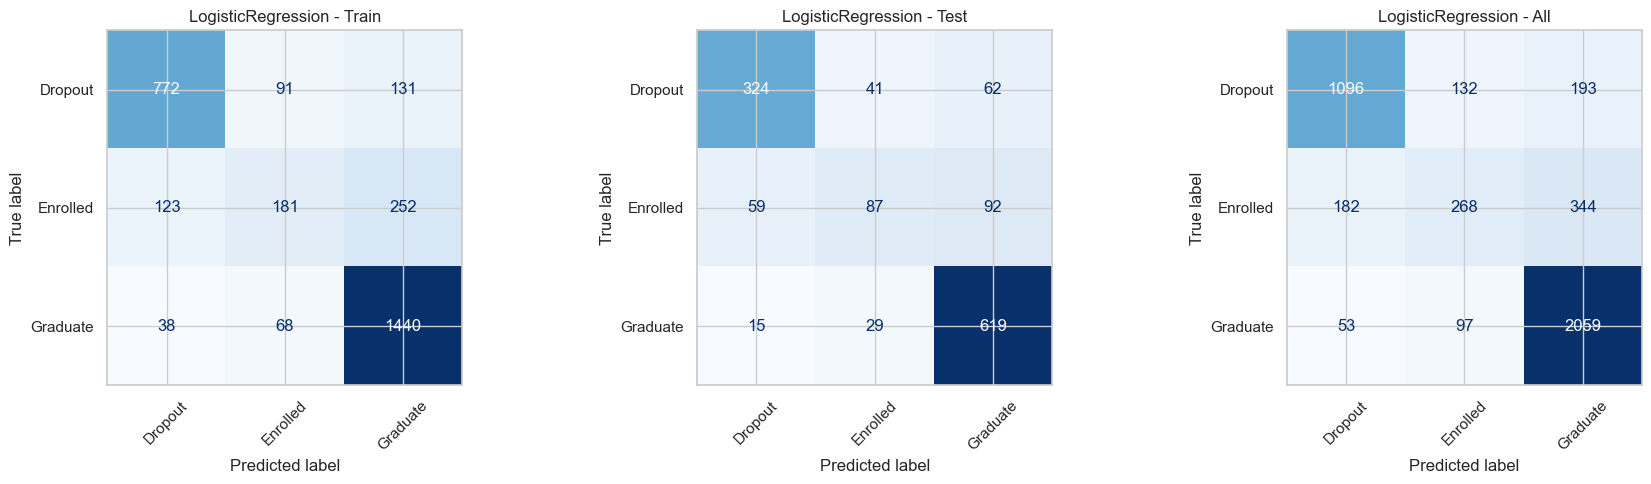

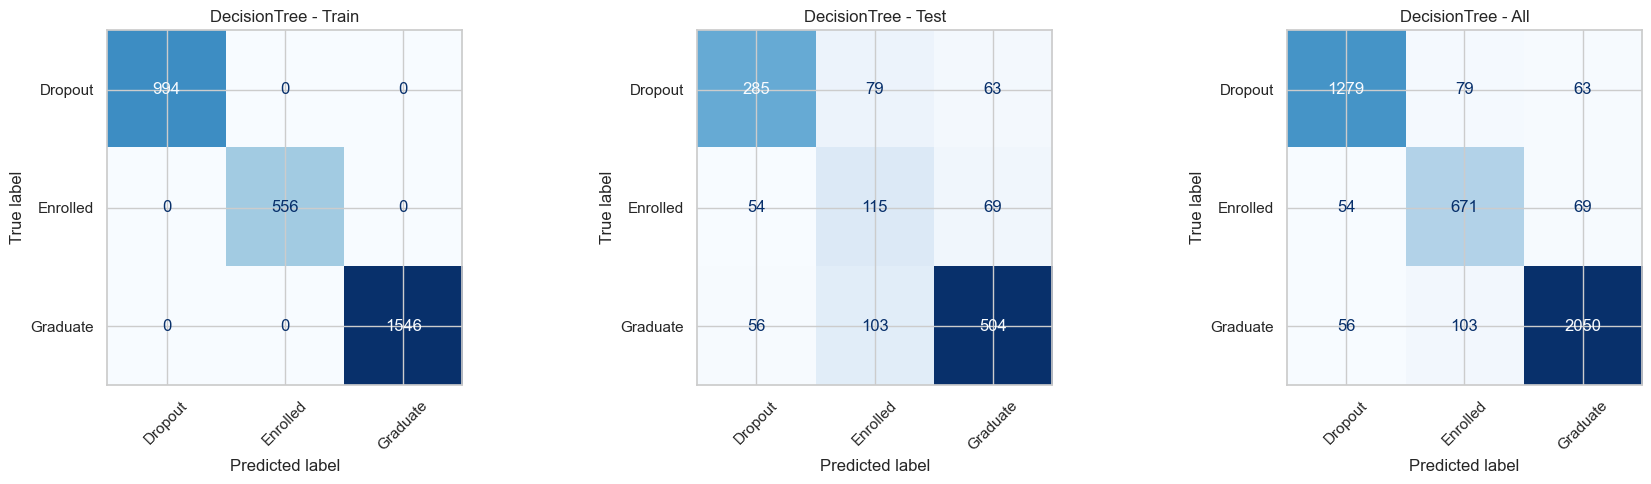

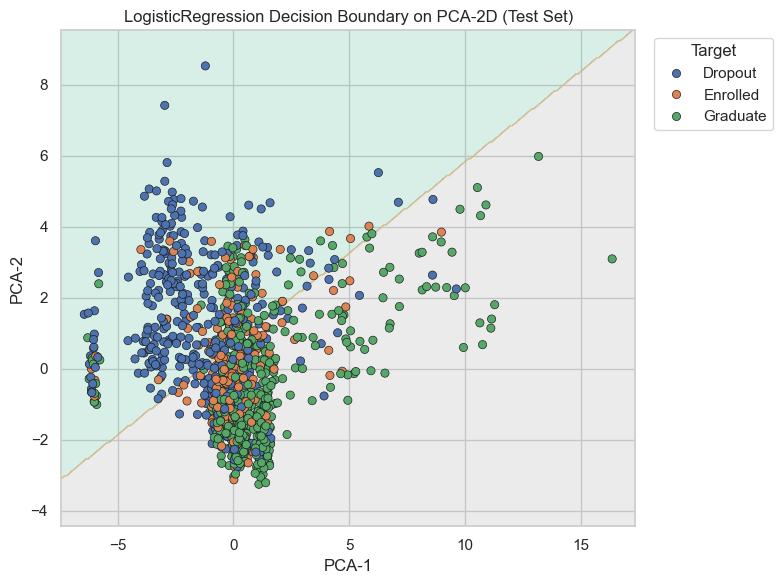

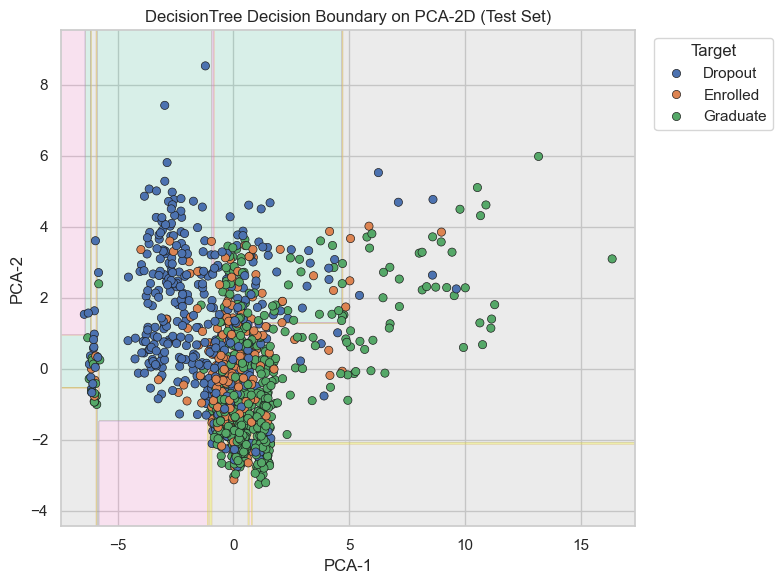

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=400, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
}

fitted_models = {}
eval_rows = []

for name, base_model in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', base_model)
    ])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    for split_name, X_split, y_split in [
        ('Train', X_train, y_train),
        ('Test', X_test, y_test),
        ('All', X, y),
    ]:
        y_pred = pipe.predict(X_split)
        eval_rows.append({
            'Model': name,
            'Split': split_name,
            'Accuracy': accuracy_score(y_split, y_pred),
            'Precision(macro)': precision_score(y_split, y_pred, average='macro'),
            'Recall(macro)': recall_score(y_split, y_pred, average='macro'),
            'F1(macro)': f1_score(y_split, y_pred, average='macro'),
        })

eval_df = pd.DataFrame(eval_rows)
display(eval_df.sort_values(['Model', 'Split']))

# Confusion matrices for Train/Test/All for each model
for name, model in fitted_models.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (split_name, X_split, y_split) in zip(axes, [('Train', X_train, y_train), ('Test', X_test, y_test), ('All', X, y)]):
        ConfusionMatrixDisplay.from_predictions(y_split, model.predict(X_split), cmap='Blues', xticks_rotation=45, ax=ax, colorbar=False)
        ax.set_title(f'{name} - {split_name}')
    plt.tight_layout()
    plt.show()

# Decision boundary visualization on 2D PCA projection (for interpretability)
X_num = df.drop(columns=[target_col]).select_dtypes(include=['number'])
X_num = X_num.fillna(X_num.median(numeric_only=True))
X_num_scaled = StandardScaler().fit_transform(X_num)
X_pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_num_scaled)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_pca2, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

viz_models = {
    'LogisticRegression': LogisticRegression(max_iter=400, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6),
}

for name, m in viz_models.items():
    m.fit(X2_train, y2_train)
    x_min, x_max = X_pca2[:, 0].min() - 1, X_pca2[:, 0].max() + 1
    y_min, y_max = X_pca2[:, 1].min() - 1, X_pca2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    class_to_code = {cls: i for i, cls in enumerate(m.classes_)}
    Z_codes = np.vectorize(class_to_code.get)(Z)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z_codes, alpha=0.25, cmap='Set2')
    sns.scatterplot(x=X2_test[:, 0], y=X2_test[:, 1], hue=y2_test, s=35, edgecolor='k')
    plt.title(f'{name} Decision Boundary on PCA-2D (Test Set)')
    plt.xlabel('PCA-1')
    plt.ylabel('PCA-2')
    plt.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Task 5: Evaluation and Choice of Prediction Model

Requirements covered:
- Accuracy, precision, recall, F1-score
- ROC curve and AUC
- Validation-based improvement for each model
- Strength/weakness interpretation support

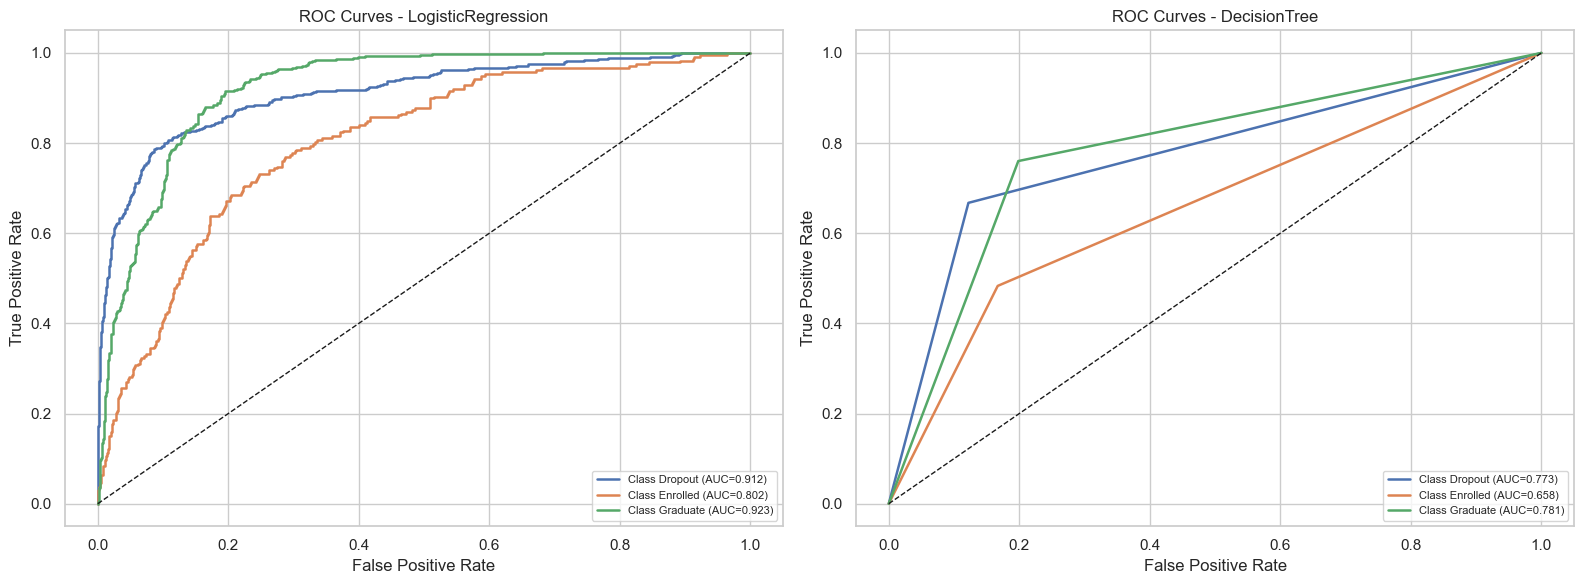

,Model,AUC (macro OVR)
0,LogisticRegression,0.879041
1,DecisionTree,0.737211


Best LogisticRegression params: {'model__C': 10.0, 'model__class_weight': 'balanced'}
Best DecisionTree params: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_split': 2}


,Model,Accuracy (test),"Precision (macro, test)","Recall (macro, test)","F1 (macro, test)"
0,LogisticRegression_tuned,0.733434,0.705950,0.707298,0.695583
1,DecisionTree_tuned,0.671687,0.692257,0.674664,0.652591



LogisticRegression_tuned
              precision    recall  f1-score   support

     Dropout       0.84      0.68      0.75       427
    Enrolled       0.41      0.64      0.50       238
    Graduate       0.86      0.80      0.83       663

    accuracy                           0.73      1328
   macro avg       0.71      0.71      0.70      1328
weighted avg       0.78      0.73      0.75      1328


DecisionTree_tuned
              precision    recall  f1-score   support

     Dropout       0.88      0.63      0.73       427
    Enrolled       0.35      0.71      0.47       238
    Graduate       0.85      0.69      0.76       663

    accuracy                           0.67      1328
   macro avg       0.69      0.67      0.65      1328
weighted avg       0.77      0.67      0.70      1328



In [18]:
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
auc_summary = []

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_score = model.predict_proba(X_test)
    macro_auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='macro')
    auc_summary.append({'Model': name, 'AUC (macro OVR)': macro_auc})

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, lw=1.8, label=f'Class {cls} (AUC={auc(fpr, tpr):.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'ROC Curves - {name}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

display(pd.DataFrame(auc_summary))

# Validation-driven improvements (GridSearchCV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logi_grid = GridSearchCV(
    Pipeline([('preprocess', preprocessor), ('model', LogisticRegression(max_iter=600, random_state=RANDOM_STATE))]),
    param_grid={
        'model__C': [0.1, 1.0, 10.0],
        'model__class_weight': [None, 'balanced']
    },
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

tree_grid = GridSearchCV(
    Pipeline([('preprocess', preprocessor), ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    param_grid={
        'model__max_depth': [None, 5, 10, 20],
        'model__min_samples_split': [2, 10, 20],
        'model__class_weight': [None, 'balanced']
    },
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

logi_grid.fit(X_train, y_train)
tree_grid.fit(X_train, y_train)

improved_models = {
    'LogisticRegression_tuned': logi_grid.best_estimator_,
    'DecisionTree_tuned': tree_grid.best_estimator_,
}

print('Best LogisticRegression params:', logi_grid.best_params_)
print('Best DecisionTree params:', tree_grid.best_params_)

comparison_rows = []
for name, model in improved_models.items():
    y_pred_test = model.predict(X_test)
    comparison_rows.append({
        'Model': name,
        'Accuracy (test)': accuracy_score(y_test, y_pred_test),
        'Precision (macro, test)': precision_score(y_test, y_pred_test, average='macro'),
        'Recall (macro, test)': recall_score(y_test, y_pred_test, average='macro'),
        'F1 (macro, test)': f1_score(y_test, y_pred_test, average='macro')
    })

display(pd.DataFrame(comparison_rows))

for name, model in improved_models.items():
    print('\n' + '=' * 60)
    print(name)
    print(classification_report(y_test, model.predict(X_test)))

## Open-ended Exploration

This section adds one more model class (Random Forest), performs cross-validation comparison, and inspects feature importance.

,Model,CV F1-macro mean,CV F1-macro std
0,LogisticRegression_tuned,0.698184,0.015667
2,RandomForest,0.686665,0.006116
1,DecisionTree_tuned,0.664400,0.013324


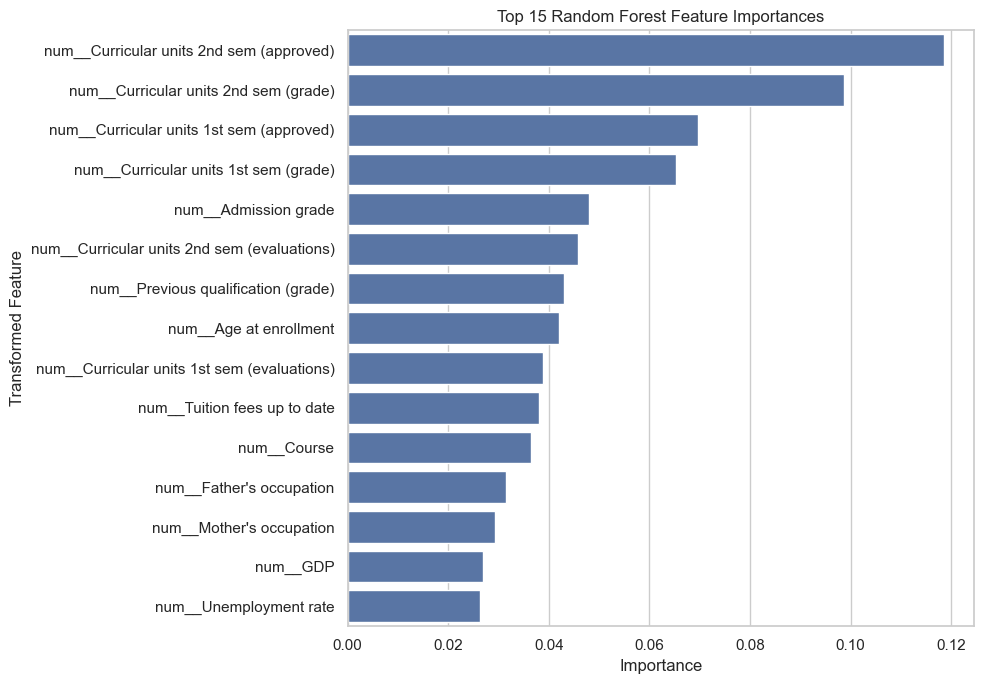

In [19]:
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300, class_weight='balanced_subsample'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_summary = []
for name, model in {
    'LogisticRegression_tuned': improved_models['LogisticRegression_tuned'],
    'DecisionTree_tuned': improved_models['DecisionTree_tuned'],
    'RandomForest': rf_pipe
}.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_summary.append({
        'Model': name,
        'CV F1-macro mean': scores.mean(),
        'CV F1-macro std': scores.std()
    })

cv_df = pd.DataFrame(cv_summary).sort_values('CV F1-macro mean', ascending=False)
display(cv_df)

# Fit random forest once and inspect top transformed feature importances
rf_pipe.fit(X_train, y_train)
rf_model = rf_pipe.named_steps['model']
feature_names = rf_pipe.named_steps['preprocess'].get_feature_names_out()
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=feat_imp.values, y=feat_imp.index, orient='h')
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Transformed Feature')
plt.tight_layout()
plt.show()

## Task 6: Similar-Class Joint Analysis (Dropout + Enrolled)

Requirement extension covered:
- Jointly analyze similar classes to reduce confusion-driven interpretation errors.
- Group-level modeling (`At-Risk` vs `Graduate`) plus subgroup modeling (`Dropout` vs `Enrolled`).
- Report confusion focus and practical decision insights.

=== Group-level model: At-Risk vs Graduate ===
              precision    recall  f1-score   support

     At-Risk       0.88      0.78      0.83       665
    Graduate       0.80      0.89      0.85       663

    accuracy                           0.84      1328
   macro avg       0.84      0.84      0.84      1328
weighted avg       0.84      0.84      0.84      1328



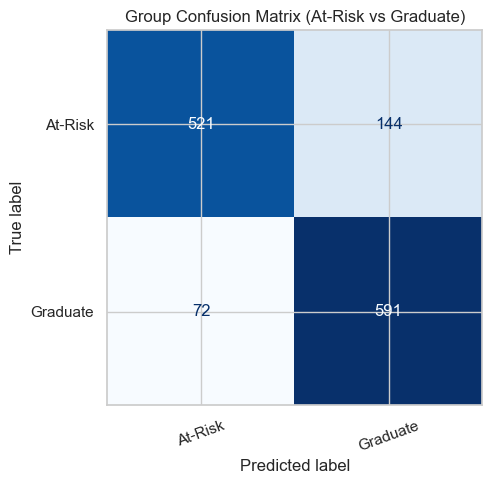


=== Subgroup model: Dropout vs Enrolled ===
              precision    recall  f1-score   support

     Dropout       0.82      0.83      0.82       427
    Enrolled       0.68      0.67      0.68       238

    accuracy                           0.77       665
   macro avg       0.75      0.75      0.75       665
weighted avg       0.77      0.77      0.77       665



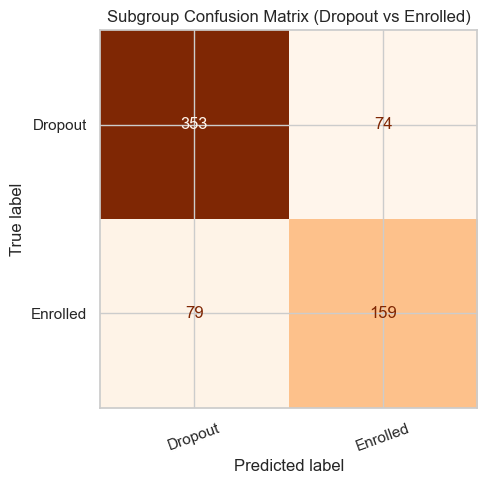


Class centroids on t-SNE plane:


,TSNE-1,TSNE-2
Target,,
Dropout,-9.416700,15.584062
Enrolled,-1.457730,0.515823
Graduate,7.333406,-9.677500


Pairwise centroid distances (smaller = more similar representation):


Target,Dropout,Enrolled,Graduate
Target,,,
Dropout,0.000000,17.041039,30.310272
Enrolled,17.041039,0.000000,13.460606
Graduate,30.310272,13.460606,0.000000



Distance Dropout-Enrolled: 17.041
Distance Dropout-Graduate: 30.310
Distance Enrolled-Graduate: 13.461
Interpretation hint: prioritize joint handling for the closest pair and inspect their misclassification trade-offs.


In [20]:
# Build a similar-class perspective:
# 1) Group model: At-Risk (Dropout+Enrolled) vs Graduate
# 2) Subgroup model: Dropout vs Enrolled inside At-Risk

y_group = y.replace({'Dropout': 'At-Risk', 'Enrolled': 'At-Risk', 'Graduate': 'Graduate'})

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X, y_group, test_size=0.30, random_state=RANDOM_STATE, stratify=y_group
)

group_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=500, random_state=RANDOM_STATE, class_weight='balanced'))
])
group_pipe.fit(X_train_g, y_train_g)

y_pred_g = group_pipe.predict(X_test_g)

print('=== Group-level model: At-Risk vs Graduate ===')
print(classification_report(y_test_g, y_pred_g))

fig, ax = plt.subplots(figsize=(5.8, 5))
ConfusionMatrixDisplay.from_predictions(y_test_g, y_pred_g, cmap='Blues', xticks_rotation=20, ax=ax, colorbar=False)
ax.set_title('Group Confusion Matrix (At-Risk vs Graduate)')
plt.tight_layout()
plt.show()

# Subgroup classifier on At-Risk only (Dropout vs Enrolled)
mask_risk = y.isin(['Dropout', 'Enrolled'])
X_risk = X.loc[mask_risk].copy()
y_risk = y.loc[mask_risk].copy()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_risk, y_risk, test_size=0.30, random_state=RANDOM_STATE, stratify=y_risk
)

risk_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=350, random_state=RANDOM_STATE, class_weight='balanced_subsample'))
])
risk_pipe.fit(X_train_r, y_train_r)

y_pred_r = risk_pipe.predict(X_test_r)

print('\n=== Subgroup model: Dropout vs Enrolled ===')
print(classification_report(y_test_r, y_pred_r))

fig, ax = plt.subplots(figsize=(5.8, 5))
ConfusionMatrixDisplay.from_predictions(y_test_r, y_pred_r, cmap='Oranges', xticks_rotation=20, ax=ax, colorbar=False)
ax.set_title('Subgroup Confusion Matrix (Dropout vs Enrolled)')
plt.tight_layout()
plt.show()

# Similar-class evidence on t-SNE plane: class centroid distances
centroids = tsne_df.groupby('Target')[['TSNE-1', 'TSNE-2']].mean()
print('\nClass centroids on t-SNE plane:')
display(centroids)

dist_df = pd.DataFrame(index=centroids.index, columns=centroids.index, dtype=float)
for c1 in centroids.index:
    for c2 in centroids.index:
        dist_df.loc[c1, c2] = np.linalg.norm(centroids.loc[c1] - centroids.loc[c2])

print('Pairwise centroid distances (smaller = more similar representation):')
display(dist_df)

# Final similarity cue for discussion
de = dist_df.loc['Dropout', 'Enrolled']
dg = dist_df.loc['Dropout', 'Graduate']
eg = dist_df.loc['Enrolled', 'Graduate']
print(f"\nDistance Dropout-Enrolled: {de:.3f}")
print(f"Distance Dropout-Graduate: {dg:.3f}")
print(f"Distance Enrolled-Graduate: {eg:.3f}")
print('Interpretation hint: prioritize joint handling for the closest pair and inspect their misclassification trade-offs.')

## Final Discussion Notes (Write-up Helper)

Use the computed tables and plots above to write your 100-200 word model-performance discussion:
- Compare train/test/all metrics to identify possible overfitting.
- Use ROC/AUC and class-level reports to discuss strengths and weaknesses by class.
- Justify your final model choice using both predictive performance and robustness (CV variance).
- Include the similar-class joint analysis:
  - Group-level (`At-Risk` vs `Graduate`) captures practical intervention value.
  - Subgroup-level (`Dropout` vs `Enrolled`) shows where fine-grained errors remain.
  - Explain how class similarity (centroid distances and confusion patterns) affects final decisions.